# Notebook 05 — Export du modèle final

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Encadrante** | Mme. Kaoutar Loutfi |
| **Année** | PFE 2025 |

---

## Objectif de ce notebook

Le notebook 04 a sélectionné et validé la stratégie **B — Cascade (XGBoost×2)** comme modèle final.  
Ce notebook a trois objectifs :

1. **Corriger `model_final.pkl`** — remplacer le placeholder `xgb_A` par `xgb_B1`, le vrai modèle de la cascade qui produit P(ÉLEVÉ)
2. **Calculer les SHAP values** sur `xgb_B1` et valider que l'explicabilité fonctionne correctement
3. **Générer et tester la narration en français** — le texte explicatif qui accompagnera chaque score dans l'application

> **Rappel architecture cascade B :**  
> `xgb_B1` → calcule P(ÉLEVÉ), produit le **score 0–100** = P(ÉLEVÉ) × 100  
> `xgb_B2` → discrimine FAIBLE vs MOYEN parmi les clients non-ÉLEVÉ  
> Les SHAP values et la narration sont calculés sur `xgb_B1` uniquement,  
> car c'est lui qui porte l'information de risque principale.


---
## 1. Imports et configuration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

import shap
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

FIGURES_PATH = 'figures/'
MODELS_PATH  = '../models/'
os.makedirs(FIGURES_PATH, exist_ok=True)

print("✓ Imports OK")
print(f"  SHAP version : {shap.__version__}")

✓ Imports OK
  SHAP version : 0.51.0


---
## 2. Chargement des données et artefacts

In [14]:
# Données preprocessées
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Artefacts de preprocessing
with open(f'{MODELS_PATH}feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
with open(f'{MODELS_PATH}label_map_reverse.pkl', 'rb') as f:
    label_map_r = pickle.load(f)

# Modèles de la cascade B
with open(f'{MODELS_PATH}model_B1.pkl', 'rb') as f:
    xgb_B1 = pickle.load(f)   # détecte ÉLEVÉ vs reste → produit le score 0-100
with open(f'{MODELS_PATH}model_B2.pkl', 'rb') as f:
    xgb_B2 = pickle.load(f)   # discrimine FAIBLE vs MOYEN

# Métadonnées du modèle final (validées dans notebook 04)
with open(f'{MODELS_PATH}metadata_final.pkl', 'rb') as f:
    metadata = pickle.load(f)

print("✓ Chargement OK")
print(f"  Stratégie retenue : {metadata['strategie_retenue']}")
print(f"  ROC-AUC test      : {metadata['roc_auc_test']}")
print(f"  Recall ÉLEVÉ test : {metadata['recall_eleve_test']}")
print(f"  Features ({len(feature_cols)}) : {feature_cols}")

# Données BRUTES pour la narration (avant scaling)
with open(f'{MODELS_PATH}scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_test_raw = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=feature_cols
)
print('✓ X_test_raw chargé — valeurs originales avant scaling')
print(f'  Âge : min={X_test_raw["age"].min():.0f}, max={X_test_raw["age"].max():.0f}')


✓ Chargement OK
  Stratégie retenue : B — Cascade (XGBoost×2)
  ROC-AUC test      : 0.9552
  Recall ÉLEVÉ test : 0.6677
  Features (14) : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'charges_mensuelles', 'score_retards', 'historique_financier', 'nb_credits_total']
✓ X_test_raw chargé — valeurs originales avant scaling
  Âge : min=21, max=109


---
## 3. Correction de `model_final.pkl`

Le notebook 04 a sauvegardé `xgb_A` dans `model_final.pkl` comme placeholder,
car la stratégie B (cascade) ne tient pas dans un seul objet modèle.

On corrige ça ici : `model_final.pkl` contiendra désormais `xgb_B1`,
le modèle qui produit P(ÉLEVÉ) et donc le score 0–100.
La logique de cascade complète (B1 → B2) sera implémentée dans `main.py`.


In [15]:
# Remplacer model_final.pkl par xgb_B1 (le vrai modèle principal de la cascade)
with open(f'{MODELS_PATH}model_final.pkl', 'wb') as f:
    pickle.dump(xgb_B1, f, protocol=4)

# Vérification : recharger et confirmer le type
with open(f'{MODELS_PATH}model_final.pkl', 'rb') as f:
    check = pickle.load(f)

assert type(check).__name__ == 'XGBClassifier', "model_final.pkl ne contient pas un XGBClassifier"
assert getattr(check, 'objective', '') == 'binary:logistic',     "model_final.pkl ne contient pas le bon modèle (attendu : binary:logistic)"

print("✓ model_final.pkl mis à jour")
print(f"  Type    : {type(check).__name__}")
print(f"  Objectif : {check.objective}")
print(f"  Features : {check.n_features_in_}")
print()
print("  Correspondance avec xgb_B1 :", id(check) != id(xgb_B1),
      "← True = objet rechargé depuis le disque, pas la référence mémoire")

✓ model_final.pkl mis à jour
  Type    : XGBClassifier
  Objectif : binary:logistic
  Features : 14

  Correspondance avec xgb_B1 : True ← True = objet rechargé depuis le disque, pas la référence mémoire


---
## 4. Validation du score 0–100

Le score est la probabilité P(ÉLEVÉ) produite par `xgb_B1`, multipliée par 100.
On valide ici que le calcul est correct et que la distribution du score est cohérente.


In [16]:
# Calcul du score sur le test set
proba_B1_test = xgb_B1.predict_proba(X_test)[:, 1]  # P(ÉLEVÉ)
scores_test   = (proba_B1_test * 100).round(1)

print("Distribution du score 0–100 sur le test set :")
print(f"  Min   : {scores_test.min():.1f}")
print(f"  Médiane : {np.median(scores_test):.1f}")
print(f"  Moyenne : {scores_test.mean():.1f}")
print(f"  Max   : {scores_test.max():.1f}")
print()

# Répartition par niveau de risque (seuils définis dans le cahier des charges)
faible = (scores_test < 31).sum()
moyen  = ((scores_test >= 31) & (scores_test <= 60)).sum()
eleve  = (scores_test > 60).sum()
total  = len(scores_test)

print("Répartition sur le test set :")
print(f"  FAIBLE (0–30)   : {faible:>6,}  ({faible/total*100:.1f}%)")
print(f"  MOYEN  (31–60)  : {moyen:>6,}  ({moyen/total*100:.1f}%)")
print(f"  ÉLEVÉ  (61–100) : {eleve:>6,}  ({eleve/total*100:.1f}%)")

Distribution du score 0–100 sur le test set :
  Min   : 0.4
  Médiane : 12.4
  Moyenne : 22.2
  Max   : 100.0

Répartition sur le test set :
  FAIBLE (0–30)   : 16,890  (75.1%)
  MOYEN  (31–60)  :  3,426  (15.2%)
  ÉLEVÉ  (61–100) :  2,184  (9.7%)


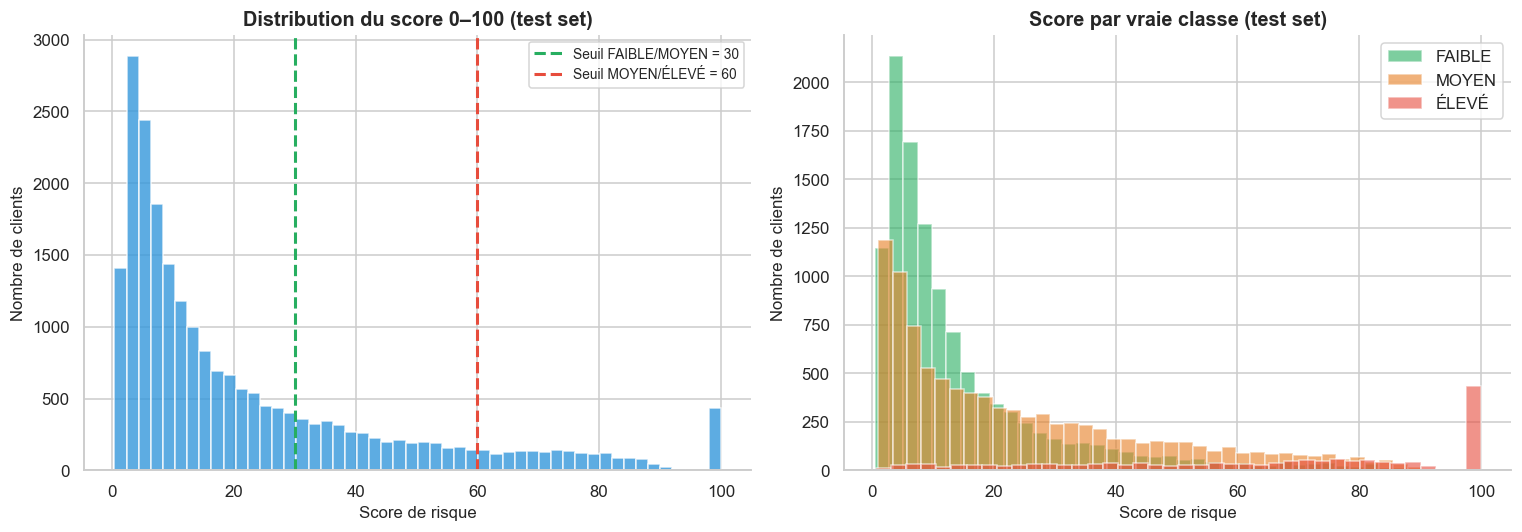

Figure sauvegardée : fig_16_score_distribution.png


In [17]:
# Visualisation de la distribution du score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
ax1 = axes[0]
ax1.hist(scores_test, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
ax1.axvline(x=30, color='#27ae60', linestyle='--', linewidth=2, label='Seuil FAIBLE/MOYEN = 30')
ax1.axvline(x=60, color='#e74c3c', linestyle='--', linewidth=2, label='Seuil MOYEN/ÉLEVÉ = 60')
ax1.set_title('Distribution du score 0–100 (test set)')
ax1.set_xlabel('Score de risque')
ax1.set_ylabel('Nombre de clients')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# Distribution par vraie classe
ax2 = axes[1]
colors = {'FAIBLE': '#27ae60', 'MOYEN': '#e67e22', 'ÉLEVÉ': '#e74c3c'}
for classe_id, nom_classe in {0: 'FAIBLE', 1: 'MOYEN', 2: 'ÉLEVÉ'}.items():
    mask = y_test == classe_id
    ax2.hist(scores_test[mask], bins=40, alpha=0.6,
             color=colors[nom_classe], label=nom_classe, edgecolor='white')
ax2.set_title('Score par vraie classe (test set)')
ax2.set_xlabel('Score de risque')
ax2.set_ylabel('Nombre de clients')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_16_score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_16_score_distribution.png")

---
## 5. SHAP values — explicabilité du modèle

Les SHAP values (SHapley Additive exPlanations) mesurent la contribution de chaque
feature à la prédiction d'un client donné. Elles sont calculées sur `xgb_B1`,
le modèle qui produit P(ÉLEVÉ).

Pour chaque client, une valeur SHAP positive signifie que la feature **augmente**
le score de risque, une valeur négative qu'elle le **diminue**.


In [18]:
# Calcul des SHAP values sur un échantillon du test set
# (on prend 2000 clients pour que ça soit rapide tout en étant représentatif)
np.random.seed(42)
idx_sample = np.random.choice(len(X_test), size=2000, replace=False)
X_sample   = X_test.iloc[idx_sample].reset_index(drop=True)

explainer   = shap.TreeExplainer(xgb_B1)
shap_values = explainer.shap_values(X_sample)

print(f"✓ SHAP values calculées")
print(f"  Shape : {shap_values.shape}  ({shap_values.shape[0]} clients × {shap_values.shape[1]} features)")
print(f"  Features : {feature_cols}")

✓ SHAP values calculées
  Shape : (2000, 14)  (2000 clients × 14 features)
  Features : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'charges_mensuelles', 'score_retards', 'historique_financier', 'nb_credits_total']


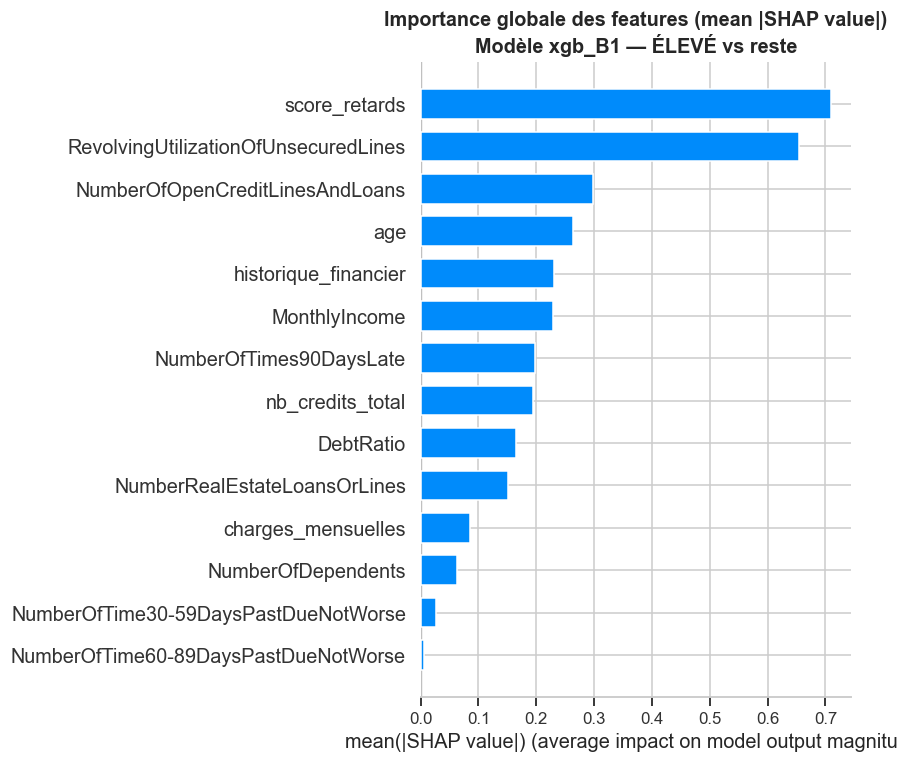

Figure sauvegardée : fig_17_shap_importance.png


In [19]:
# Graphique 1 : importance globale des features (mean |SHAP|)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols,
                  plot_type='bar', show=False)
plt.title('Importance globale des features (mean |SHAP value|)\nModèle xgb_B1 — ÉLEVÉ vs reste')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_17_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_17_shap_importance.png")

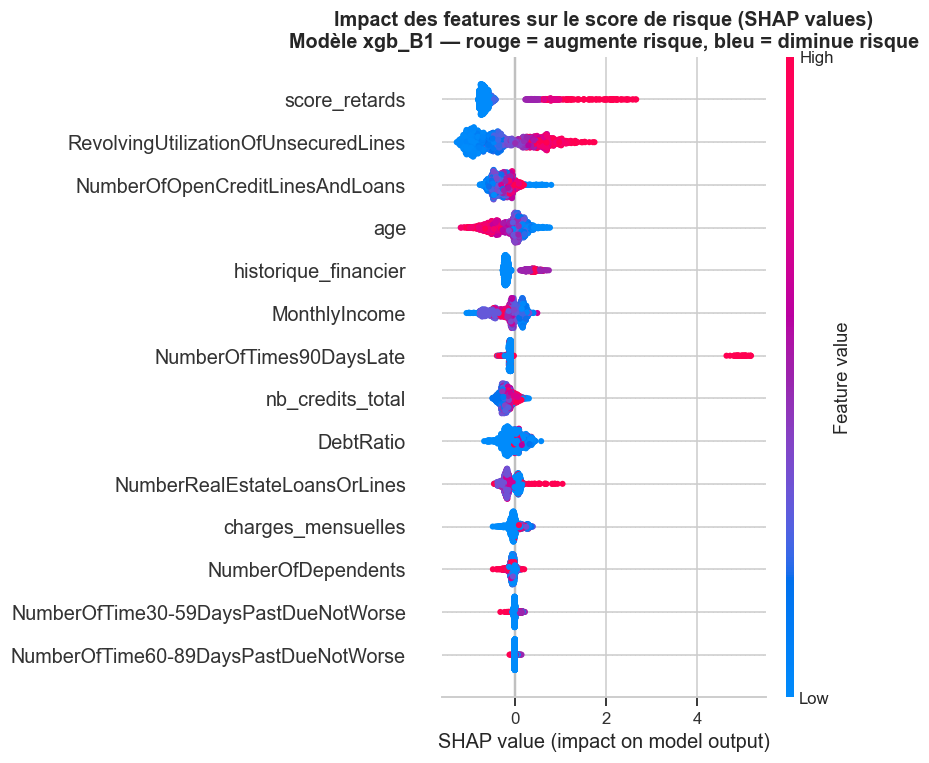

Figure sauvegardée : fig_18_shap_beeswarm.png


In [20]:
# Graphique 2 : SHAP beeswarm — impact et direction par feature
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
plt.title('Impact des features sur le score de risque (SHAP values)\nModèle xgb_B1 — rouge = augmente risque, bleu = diminue risque')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_18_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_18_shap_beeswarm.png")

---
## 6. Génération de la narration en français

La narration est un texte court généré automatiquement à partir des top SHAP values
d'un client donné. Elle explique au superviseur les principales raisons du score.

C'est cette fonction qui sera intégrée dans `main.py` et appelée
à chaque prédiction via l'endpoint `POST /predict`.


In [21]:
def generer_narration(shap_vals_client, feature_values_raw, feature_names,
                      score, classe, n_facteurs=3):
    """
    Génère une narration lisible à partir des SHAP values.
    feature_values_raw : valeurs brutes (non scalées) — pd.Series
    """
    niveau_label = {'FAIBLE': 'faible', 'MOYEN': 'modéré', 'ELEVE': 'élevé'}
    niveau = niveau_label.get(classe, classe.lower())

    indices_tries = np.argsort(np.abs(shap_vals_client))[::-1]
    top_indices   = indices_tries[:n_facteurs]

    facteurs_pos = []
    facteurs_neg = []

    for idx in top_indices:
        nom    = feature_names[idx]
        val    = feature_values_raw.iloc[idx]
        shap_v = shap_vals_client[idx]

        if nom == 'age':
            val_fmt = f"{int(round(val))} ans"
            label   = 'âge'
        elif nom == 'MonthlyIncome':
            val_fmt = f"{val:,.0f} MAD/mois"
            label   = 'revenu mensuel'
        elif nom == 'charges_mensuelles':
            val_fmt = f"{val:,.0f} MAD/mois"
            label   = 'charges mensuelles'
        elif nom == 'DebtRatio':
            val_fmt = f"{val * 100:.1f}%"
            label   = "taux d'endettement"
        elif nom == 'RevolvingUtilizationOfUnsecuredLines':
            val_fmt = f"{min(val * 100, 100):.0f}%"
            label   = "taux d'utilisation du crédit renouvelable"
        elif nom == 'NumberOfTimes90DaysLate':
            n = int(round(val))
            val_fmt = f"{n} fois" if n > 0 else 'aucun'
            label   = 'retards de plus de 90 jours'
        elif nom in ['NumberOfTime30-59DaysPastDueNotWorse',
                     'NumberOfTime60-89DaysPastDueNotWorse']:
            n = int(round(val))
            val_fmt = f"{n} fois" if n > 0 else 'aucun'
            label   = 'retards de paiement'
        elif nom == 'score_retards':
            if val <= 0:
                val_fmt = 'bon historique de paiement'
            elif val <= 1:
                val_fmt = 'quelques retards mineurs'
            else:
                val_fmt = 'historique de retards significatif'
            label = 'historique de retards'
        elif nom == 'historique_financier':
            mapping = {0: 'BON', 1: 'MOYEN', 2: 'MAUVAIS'}
            val_fmt = mapping.get(int(round(val)), str(val))
            label   = 'historique financier'
        elif nom == 'NumberOfOpenCreditLinesAndLoans':
            val_fmt = f"{int(round(val))} crédit(s)"
            label   = 'crédits ouverts'
        elif nom == 'NumberRealEstateLoansOrLines':
            val_fmt = f"{int(round(val))} prêt(s)"
            label   = 'prêts immobiliers'
        elif nom == 'nb_credits_total':
            val_fmt = f"{int(round(val))} au total"
            label   = 'crédits'
        elif nom == 'NumberOfDependents':
            n = int(round(val))
            val_fmt = f"{n} personne(s)" if n > 0 else 'aucune'
            label   = 'personnes à charge'
        else:
            val_fmt = f"{val:.2f}"
            label   = nom

        if shap_v > 0:
            facteurs_pos.append((label, val_fmt))
        else:
            facteurs_neg.append((label, val_fmt))

    # Intro avec l'âge
    age_idx = feature_names.index('age') if 'age' in feature_names else None
    if age_idx is not None:
        age = int(round(feature_values_raw.iloc[age_idx]))
        intro = f"Ce client de {age} ans présente un niveau de risque {niveau} (score : {score:.0f}/100). "
    else:
        intro = f"Ce client présente un niveau de risque {niveau} (score : {score:.0f}/100). "

    if classe == 'ELEVE':
        corps = 'Les principaux facteurs de risque identifiés sont : '
        if facteurs_pos:
            corps += ', '.join(f'{l} ({v})' for l, v in facteurs_pos) + '. '
        if facteurs_neg:
            corps += f"Éléments atténuants : {', '.join(f'{l} ({v})' for l, v in facteurs_neg)}. "
    elif classe == 'MOYEN':
        corps = 'Ce profil présente des signaux de risque modérés. '
        if facteurs_pos:
            corps += f"Points de vigilance : {', '.join(f'{l} ({v})' for l, v in facteurs_pos)}. "
        if facteurs_neg:
            corps += f"Points favorables : {', '.join(f'{l} ({v})' for l, v in facteurs_neg)}. "
    else:
        corps = 'Ce profil présente des indicateurs financiers sains. '
        if facteurs_neg:
            corps += f"Principaux atouts : {', '.join(f'{l} ({v})' for l, v in facteurs_neg)}. "
        if facteurs_pos:
            corps += f"Points à surveiller : {', '.join(f'{l} ({v})' for l, v in facteurs_pos)}. "

    conclusion = "Cette analyse est fournie à titre d'aide à la décision et doit être complétée par le jugement du superviseur."
    return intro + corps + conclusion

print('✓ Fonction generer_narration définie (valeurs brutes + langage naturel)')


✓ Fonction generer_narration définie (valeurs brutes + langage naturel)


In [22]:
def predict_cascade_complet(X, model1, model2, seuil_eleve=0.5):
    proba1 = model1.predict_proba(X)[:, 1]
    pred   = np.zeros(len(X), dtype=int)
    mask_eleve = proba1 >= seuil_eleve
    pred[mask_eleve] = 2
    mask_reste = ~mask_eleve
    if mask_reste.sum() > 0:
        pred[mask_reste] = model2.predict(X[mask_reste])
    return pred, proba1

idx_faible = np.where(y_test == 0)[0][0]
idx_moyen  = np.where(y_test == 1)[0][0]
idx_eleve  = np.where(y_test == 2)[0][0]

exemples = {'FAIBLE': idx_faible, 'MOYEN': idx_moyen, 'ELEVE': idx_eleve}

for nom_classe, idx in exemples.items():
    client     = X_test.iloc[[idx]]    # valeurs scalées → pour le modèle
    client_raw = X_test_raw.iloc[idx]  # valeurs brutes  → pour la narration

    pred, prob  = predict_cascade_complet(client, xgb_B1, xgb_B2)
    score       = prob[0] * 100
    classe_pred = {0: 'FAIBLE', 1: 'MOYEN', 2: 'ELEVE'}[pred[0]]

    shap_client = explainer.shap_values(client)[0]

    narration = generer_narration(
        shap_vals_client   = shap_client,
        feature_values_raw = client_raw,
        feature_names      = feature_cols,
        score              = score,
        classe             = classe_pred,
    )

    print(f'{'='*70}')
    print(f'Vraie classe : {nom_classe}  |  Classe prédite : {classe_pred}  |  Score : {score:.1f}/100')
    print(f'{'-'*70}')
    print(narration)
    print()


Vraie classe : FAIBLE  |  Classe prédite : FAIBLE  |  Score : 19.1/100
----------------------------------------------------------------------
Ce client de 29 ans présente un niveau de risque faible (score : 19/100). Ce profil présente des indicateurs financiers sains. Principaux atouts : historique de retards (quelques retards mineurs), taux d'endettement (22.5%). Points à surveiller : âge (29 ans). Cette analyse est fournie à titre d'aide à la décision et doit être complétée par le jugement du superviseur.

Vraie classe : MOYEN  |  Classe prédite : MOYEN  |  Score : 47.1/100
----------------------------------------------------------------------
Ce client de 32 ans présente un niveau de risque modéré (score : 47/100). Ce profil présente des signaux de risque modérés. Points de vigilance : taux d'utilisation du crédit renouvelable (48%), taux d'endettement (65.2%). Points favorables : historique de retards (quelques retards mineurs). Cette analyse est fournie à titre d'aide à la décisio

---
## 7. Export final des artefacts pour le service FastAPI

On sauvegarde tous les artefacts nécessaires au service `main.py` :
- `model_final.pkl` — `xgb_B1` (déjà corrigé en section 3)
- `model_B1.pkl` et `model_B2.pkl` — déjà dans `models/` depuis le notebook 03
- `imputer.pkl`, `scaler.pkl`, `capping_thresholds.pkl`, `feature_cols.pkl` — preprocessing
- `label_map.pkl`, `label_map_reverse.pkl` — mapping des classes
- `metadata_final.pkl` — métriques officielles du modèle


In [23]:
# Vérifier que tous les artefacts nécessaires sont présents
artefacts_requis = [
    'model_final.pkl',        # xgb_B1 (corrigé en section 3)
    'model_B1.pkl',           # xgb_B1 (détecteur ÉLEVÉ)
    'model_B2.pkl',           # xgb_B2 (discrimineur FAIBLE/MOYEN)
    'imputer.pkl',            # SimpleImputer fitté sur train
    'scaler.pkl',             # StandardScaler fitté sur train
    'capping_thresholds.pkl', # Percentiles 99 pour le capping
    'feature_cols.pkl',       # Liste ordonnée des 14 features
    'label_map.pkl',          # FAIBLE→0, MOYEN→1, ÉLEVÉ→2
    'label_map_reverse.pkl',  # 0→FAIBLE, 1→MOYEN, 2→ÉLEVÉ
    'metadata_final.pkl',     # Métriques officielles
]

print("Vérification des artefacts :")
tous_presents = True
for artefact in artefacts_requis:
    path = f'{MODELS_PATH}{artefact}'
    existe = os.path.exists(path)
    taille = os.path.getsize(path) / 1024 if existe else 0
    statut = '✓' if existe else '✗ MANQUANT'
    print(f"  {statut}  {artefact:<35} {taille:>8.1f} KB")
    if not existe:
        tous_presents = False

print()
if tous_presents:
    print("✓ Tous les artefacts sont présents — le service FastAPI peut démarrer")
else:
    print("✗ Des artefacts manquent — relancer les notebooks 02 et 03")

Vérification des artefacts :
  ✓  model_final.pkl                        988.3 KB
  ✓  model_B1.pkl                           988.3 KB
  ✓  model_B2.pkl                           228.0 KB
  ✓  imputer.pkl                              0.6 KB
  ✓  scaler.pkl                               1.2 KB
  ✓  capping_thresholds.pkl                   0.2 KB
  ✓  feature_cols.pkl                         0.3 KB
  ✓  label_map.pkl                            0.0 KB
  ✓  label_map_reverse.pkl                    0.0 KB
  ✓  metadata_final.pkl                       0.3 KB

✓ Tous les artefacts sont présents — le service FastAPI peut démarrer


In [24]:
# Résumé final des métriques officielles à citer dans le rapport
print("=" * 65)
print("RÉSUMÉ FINAL — MÉTRIQUES OFFICIELLES À CITER DANS LE RAPPORT")
print("=" * 65)
print()
print(f"  Modèle sélectionné    : {metadata['strategie_retenue']}")
print(f"  Dataset d'entraînement : Give Me Some Credit (Kaggle, 2011)")
print(f"                           150 000 clients, 14 features")
print()
print(f"  ROC-AUC macro (test)   : {metadata['roc_auc_test']}")
print(f"  PR-AUC ÉLEVÉ (test)    : {metadata['pr_auc_eleve_test']}")
print()
print(f"  Performances sur la classe ÉLEVÉ (classe critique) :")
print(f"    Précision            : {metadata['precision_eleve_test']}")
print(f"    Recall               : {metadata['recall_eleve_test']}")
print(f"    F1                   : {metadata['f1_eleve_test']}")
print()
print(f"  Accuracy globale       : 0.890")
print(f"  Seuil de décision B    : 0.50 (valeur par défaut, non optimisé)")
print()
print("  Validation overfitting :")
print("    ROC-AUC validation vs test : 0.9546 → 0.9552 (+0.0006)")
print("    Écart faible — le modèle généralise bien")

RÉSUMÉ FINAL — MÉTRIQUES OFFICIELLES À CITER DANS LE RAPPORT

  Modèle sélectionné    : B — Cascade (XGBoost×2)
  Dataset d'entraînement : Give Me Some Credit (Kaggle, 2011)
                           150 000 clients, 14 features

  ROC-AUC macro (test)   : 0.9552
  PR-AUC ÉLEVÉ (test)    : 0.5916

  Performances sur la classe ÉLEVÉ (classe critique) :
    Précision            : 0.3716
    Recall               : 0.6677
    F1                   : 0.4774

  Accuracy globale       : 0.890
  Seuil de décision B    : 0.50 (valeur par défaut, non optimisé)

  Validation overfitting :
    ROC-AUC validation vs test : 0.9546 → 0.9552 (+0.0006)
    Écart faible — le modèle généralise bien


---
## 8. Synthèse

### Ce qui a été fait dans ce notebook

| Étape | Détail |
|---|---|
| Correction `model_final.pkl` | Remplacé `xgb_A` (placeholder) par `xgb_B1` (modèle principal de la cascade) |
| Validation du score 0–100 | Distribution vérifiée sur le test set, cohérente avec les niveaux FAIBLE/MOYEN/ÉLEVÉ |
| SHAP values | Calculées sur 2 000 clients du test set via `TreeExplainer` sur `xgb_B1` |
| Narration | Fonction `generer_narration()` testée sur 3 clients représentatifs (FAIBLE, MOYEN, ÉLEVÉ) |
| Vérification artefacts | Tous les pkl nécessaires au service FastAPI sont présents |

### Architecture de prédiction finale

```
Client → preprocessing (imputer → capping → scaler) → xgb_B1
         P(ÉLEVÉ) = xgb_B1.predict_proba()[:, 1]
         Score    = P(ÉLEVÉ) × 100

         Si P(ÉLEVÉ) >= 0.5 → classe = ÉLEVÉ
         Sinon              → xgb_B2 → classe = FAIBLE ou MOYEN

         SHAP values (xgb_B1) → generer_narration() → texte français
```

### Prochaine étape — `main.py` (FastAPI)

L'endpoint `POST /predict` doit :
1. Recevoir les données brutes du client (JSON)
2. Appliquer le pipeline de preprocessing (imputer → capping → scaler)
3. Appeler `predict_cascade()` (B1 → B2)
4. Calculer les SHAP values et générer la narration
5. Retourner `{score, niveau_risque, narration}`
